In [149]:
import pickle
import os
from snowflake.snowpark import Session
import snowflake.snowpark.functions as sfunc
from dotenv import load_dotenv
import polars
import math
import numpy as np

load_dotenv()

True

In [4]:
with open('data/ai_skill_ids.pkl', 'rb') as f:
    ai = pickle.load(f)

In [150]:
# connecting to the snowflake database
connection_parameters = {
    "user": os.getenv("SNOWFLAKE_USER"),
    "password": os.getenv("SNOWFLAKE_PASSWORD"),
    "account": os.getenv("SNOWFLAKE_ACCOUNT"),
    "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE"),
    "database": os.getenv("SNOWFLAKE_DATABASE"),
    "schema": os.getenv("SNOWFLAKE_SCHEMA"),
}
session = Session.builder.configs(connection_parameters).create()

In [151]:
posts_sp = session.read.table("OII_US_10M_SAMP_POSTS3")
skills_sp = session.read.table("OII_US_10M_SAMP_SKILLS3")

In [152]:
ai_ids_sp = skills_sp.filter(
        (sfunc.col("SKILL_SUBCATEGORY_NAME") == 'Artificial Intelligence and Machine Learning (AI/ML)') &
        (~sfunc.col("SKILL_NAME").isin(["Machine Learning", "Artificial Intelligence"]))
    ) \
    .select(
        sfunc.col("ID").alias("ID2"),
        sfunc.lit(True).alias("AI ROLE")
    ).distinct()

In [153]:
posts_df = posts_sp \
    .filter(sfunc.col("IS_INTERNSHIP") == False) \
    .join(ai_ids_sp, posts_sp["ID"] == ai_ids_sp["ID2"], "left") \
    .select(
        posts_sp["ID"].alias("ID"),
        sfunc.col("BODY"),
        sfunc.col("POSTED"),
        sfunc.year(sfunc.col("POSTED")).alias("YEAR"),
        sfunc.quarter(sfunc.col("POSTED")).alias("QUARTER"),
        sfunc.col("COMPANY_NAME"),
        sfunc.col("NAICS_2022_2_NAME"),
        sfunc.col("SOC_2021_2_NAME"),
        sfunc.col("STATE_NAME"),
        sfunc.col("COUNTY_NAME"),
        sfunc.col("MIN_EDULEVELS_NAME"),
        sfunc.col("MIN_YEARS_EXPERIENCE"),
        sfunc.col("SALARY"),
        sfunc.col("AI ROLE")
    ) \
    .na.fill({"AI ROLE": False}) \
    .to_pandas()

In [154]:
posts_df.to_parquet('../../../VData/scro4406/initial_data.parquet', index=False)

In [155]:
len(posts_df[(posts_df["AI"]==1) & (posts_df["SALARY"].notna())]) / len(posts_df[posts_df["AI"]==1])

KeyError: 'AI'

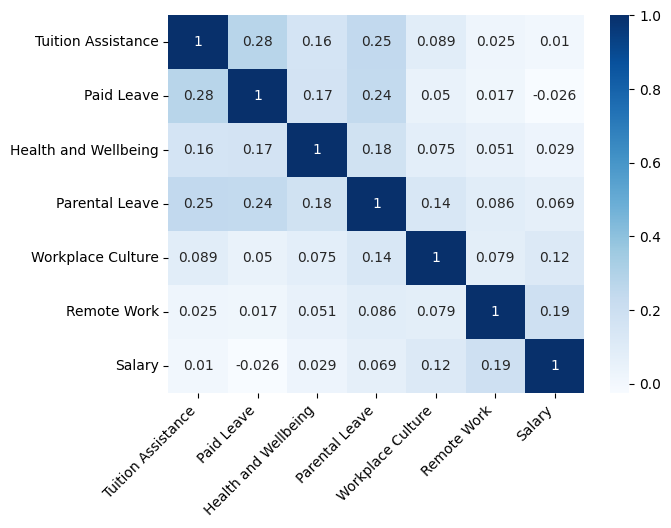

In [156]:
import polars as pl
import pandas as pd
from src.package_files.benefits_defns import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
path_all = '../../../VData/scro4406/labeled_v1.parquet'
remote_kw = '../../../VData/scro4406/data_v2.parquet'
usdf = pl.scan_parquet(path_all)
remote_df = pl.scan_parquet(remote_kw)
usdf = usdf.join(remote_df.select(['ID', 'REMOTE_KW']), on='ID', how='left')
df_select = usdf.select(benefits4+['SALARY'])
df_salary = df_select.filter(pl.col('SALARY').is_not_null()).collect().to_pandas()
df_select = df_select.collect().to_pandas()
correlation_matrix = df_salary.corr()
correlation_matrix
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', cbar = True)
plt.xticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Salary'], rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Salary'], rotation=0, va='center')
# add margin to the bottom of the plot
plt.subplots_adjust(bottom=0.25, left=0.25)
plt.savefig('./figures/benefits_correlation.png')

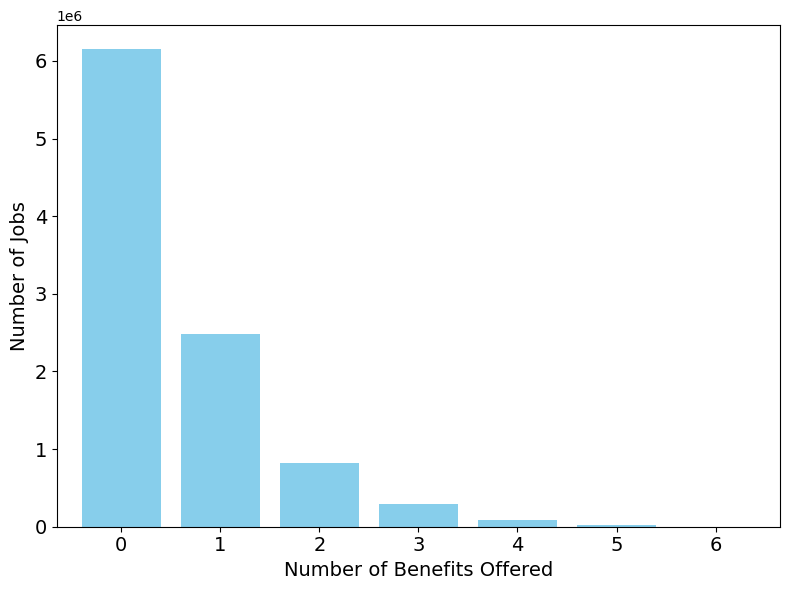

In [47]:

df_select['Benefit Count'] = df_select[benefits4].sum(axis=1)

# Assuming df_select is your DataFrame and 'Benefit Count' is already created
# Count the number of rows for each unique value in 'Benefit Count'
benefit_count_distribution = df_select['Benefit Count'].value_counts().sort_index()

# Plot the distribution as a bar chart
plt.figure(figsize=(8, 6))
ax = benefit_count_distribution.plot(kind='bar', color='skyblue', width=0.8)  # Adjust width to reduce space between bars
# ax.ticklabel_format(style='plain', axis='y')
ax.set_xticklabels(benefit_count_distribution.index.astype(int), rotation = 0, fontsize = 14)
ax.yaxis.set_tick_params(labelsize=14)


# Add labels and title
# plt.title('Number of Rows per Benefit Count', fontsize=16)
plt.xlabel('Number of Benefits Offered', fontsize=14)
plt.ylabel('Number of Jobs', fontsize=14)

# Show the plot
plt.tight_layout()
plt.savefig('./figures/num_jobs_num_benefits_2024.png')
plt.show()

In [157]:
usdf.collect_schema()

Schema([('ID', String),
        ('BODY', String),
        ('POSTED', Date),
        ('YEAR', Int16),
        ('QUARTER', Int8),
        ('COMPANY_NAME', String),
        ('NAICS_2022_2_NAME', String),
        ('SOC_2021_2_NAME', String),
        ('STATE_NAME', String),
        ('COUNTY_NAME', String),
        ('MIN_EDULEVELS_NAME', String),
        ('MIN_YEARS_EXPERIENCE', Float64),
        ('SALARY', Float64),
        ('AI ROLE', Boolean),
        ('EXPERIENCE_BUCKET', String),
        ('LOG_SALARY', Float64),
        ('EDU_ASSISTANCE', Boolean),
        ('PAID LEAVE', Boolean),
        ('WELLBEING', Boolean),
        ('HEALTH_WELLBEING', Boolean),
        ('PARENTAL_LEAVE', Boolean),
        ('CULTURE', Boolean),
        ('REMOTE_KW', Boolean)])

In [158]:
usdf \
    .select(
        pl.col("SALARY").is_not_null().alias("HAS_SALARY"),
        pl.col("AI ROLE")
    ).mean().collect()

HAS_SALARY,AI ROLE
f64,f64
0.29754,0.005881


In [159]:
display(usdf.select(["AI ROLE"]+benefits4).group_by("AI ROLE").mean().collect())

AI ROLE,EDU_ASSISTANCE,PAID LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW
bool,f64,f64,f64,f64,f64,f64
false,0.076166,0.249894,0.043122,0.034576,0.092046,0.060001
true,0.071838,0.214395,0.051584,0.064846,0.183307,0.154183


In [35]:
exp_df = usdf \
    .group_by("EXPERIENCE_BUCKET") \
    .len().collect().to_pandas()
exp_df["len"] = exp_df["len"] / 9872624
exp_df

,EXPERIENCE_BUCKET,len
0,None Listed,0.545016
1,6-10 years,0.052741
2,0 years,0.033000
3,3-5 years,0.155106
4,1-2 years,0.207160
5,11-20 years,0.006978


In [52]:
educ_df = usdf \
    .group_by("MIN_EDULEVELS_NAME") \
    .len().collect().to_pandas()
educ_df["len"] = educ_df["len"] / 9872624
educ_df

,MIN_EDULEVELS_NAME,len
0,Ph.D. or professional degree,0.008707
1,Associate degree,0.048881
2,Bachelor's degree,0.206049
3,No Education Listed,0.484298
4,Master's degree,0.020753
5,High school or GED,0.231313


In [4]:
usdf.collect_schema()

Schema([('ID', String),
        ('BODY', String),
        ('POSTED', Date),
        ('YEAR', Int16),
        ('QUARTER', Int8),
        ('NAICS_2022_2_NAME', String),
        ('SOC_2021_2_NAME', String),
        ('STATE_NAME', String),
        ('COUNTY_NAME', String),
        ('MIN_EDULEVELS_NAME', String),
        ('MIN_YEARS_EXPERIENCE', Float64),
        ('SALARY', Float64),
        ('AI ROLE', Boolean),
        ('EXPERIENCE_BUCKET', String),
        ('LOG_SALARY', Float64),
        ('EDU_ASSISTANCE', Boolean),
        ('PAID LEAVE', Boolean),
        ('WELLBEING', Boolean),
        ('HEALTH_WELLBEING', Boolean),
        ('PARENTAL_LEAVE', Boolean),
        ('CULTURE', Boolean),
        ('REMOTE_KW', Boolean)])

In [144]:
agg_col = "NAICS_2022_2_NAME"
tot_df = usdf \
    .group_by([agg_col, "YEAR"]) \
    .agg(
        (pl.count("ID")).alias("TOT_JOBS"),
        (pl.median("SALARY")).alias("MEDIAN_SALARY_TOT"),
        (pl.mean("AI ROLE").cast(pl.Float64)).alias("PCT_AI_ROLES"),
        (pl.sum("EDU_ASSISTANCE") / pl.count("ID")).alias("PCT_EDU_ASSISTANCE_TOT"),
        (pl.sum("PAID LEAVE") / pl.count("ID")).alias("PCT_PAID_LEAVE_TOT"),
        (pl.sum("HEALTH_WELLBEING") / pl.count("ID")).alias("PCT_HEALTH_WELLBEING_TOT"),
        (pl.sum("PARENTAL_LEAVE") / pl.count("ID")).alias("PCT_PARENTAL_LEAVE_TOT"),
        (pl.sum("CULTURE") / pl.count("ID")).alias("PCT_CULTURE_TOT"),
        (pl.sum("REMOTE_KW") / pl.count("ID")).alias("PCT_REMOTE_KW_TOT")
    ).collect().to_pandas()

agg_df = usdf \
    .group_by([agg_col, "YEAR", "AI ROLE"]) \
    .agg(
        (pl.sum("EDU_ASSISTANCE") / pl.count("ID")).alias("PCT_EDU_ASSISTANCE"),
        (pl.sum("PAID LEAVE") / pl.count("ID")).alias("PCT_PAID_LEAVE"),
        (pl.sum("HEALTH_WELLBEING") / pl.count("ID")).alias("PCT_HEALTH_WELLBEING"),
        (pl.sum("PARENTAL_LEAVE") / pl.count("ID")).alias("PCT_PARENTAL_LEAVE"),
        (pl.sum("CULTURE") / pl.count("ID")).alias("PCT_CULTURE"),
        (pl.sum("REMOTE_KW") / pl.count("ID")).alias("PCT_REMOTE_KW"),
        (pl.count("ID")).alias("NUM_JOBS"),
        (pl.median("SALARY")).alias("MEDIAN_SALARY")
    ).collect().to_pandas()
agg_ai_df = agg_df[agg_df["AI ROLE"]==True]
agg_nonai_df = agg_df[agg_df["AI ROLE"]==False]
agg_df = pd.merge(agg_ai_df, agg_nonai_df, on=[agg_col, "YEAR"], suffixes=("_AI", "_NONAI"))
agg_df = pd.merge(agg_df, tot_df, on=[agg_col, "YEAR"])
agg_df["SALARY_DIFF"] = agg_df["MEDIAN_SALARY_AI"] / agg_df["MEDIAN_SALARY_NONAI"]
agg_df["LOG_TOT_JOBS"] = np.log(agg_df["TOT_JOBS"])

In [148]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

def run_model(dep_var, df):
    model1 = smf.glm(f"{dep_var}_AI ~ PCT_AI_ROLES + C(YEAR)", data=df, family=sm.families.Binomial()).fit(cov_type='HC0')
    model2 = smf.glm(f"{dep_var}_AI ~ PCT_AI_ROLES + {dep_var}_TOT + C(YEAR)", data=df, family=sm.families.Binomial()).fit(cov_type='HC0')
    return model1, model2

edu_assistance_model1, edu_assistance_model2 = run_model("PCT_EDU_ASSISTANCE", agg_df)
paid_leave_model1, paid_leave_model2 = run_model("PCT_PAID_LEAVE", agg_df)
health_wellbeing_model1, health_wellbeing_model2 = run_model("PCT_HEALTH_WELLBEING", agg_df)
parental_leave_model1, parental_leave_model2 = run_model("PCT_PARENTAL_LEAVE", agg_df)
culture_model1, culture_model2 = run_model("PCT_CULTURE", agg_df)
remote_kw_model1, remote_kw_model2 = run_model("PCT_REMOTE_KW", agg_df)

def model_results(models, response):
    
    table = summary_col(
        models,
        regressor_order = [
            "PCT_AI_ROLES"
        ],
        stars=True,
        float_format='%0.2f',
        info_dict={
            'N':lambda x: "{0:d}".format(int(x.nobs)),
            'AIC':lambda x: "{:.2f}".format(x.aic)
        }
    )

    # if response == "AI_DUMMY":
    #     print(f"Average Marginal Effect for {response} - Substitute: {model2.get_margeff().summary_frame().loc[response, 'dy/dx']:.4%}")
    #     print(f"Average Marginal Effect for {response} - Complement: {model4.get_margeff().summary_frame().loc[response, 'dy/dx']:.4%}")
    # else:
    #     print(f"Average Marginal Effect for {response} - Substitute: {model2.get_margeff().summary_frame().loc[response, 'dy/dx'] / 100:.4%}")
    #     print(f"Average Marginal Effect for {response} - Complement: {model4.get_margeff().summary_frame().loc[response, 'dy/dx'] / 100:.4%}")
    print(table.as_latex())

model_results([
    edu_assistance_model1, 
    edu_assistance_model2, 
    paid_leave_model1, 
    paid_leave_model2, 
    health_wellbeing_model1, 
    health_wellbeing_model2, 
    parental_leave_model1, 
    parental_leave_model2, 
    culture_model1, 
    culture_model2, 
    remote_kw_model1, 
    remote_kw_model2
], "PCT_AI_ROLES")

\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllllllllll}
\hline
                            & PCT\_EDU\_ASSISTANCE\_AI I & PCT\_EDU\_ASSISTANCE\_AI II & PCT\_PAID\_LEAVE\_AI I & PCT\_PAID\_LEAVE\_AI II & PCT\_HEALTH\_WELLBEING\_AI I & PCT\_HEALTH\_WELLBEING\_AI II & PCT\_PARENTAL\_LEAVE\_AI I & PCT\_PARENTAL\_LEAVE\_AI II & PCT\_CULTURE\_AI I & PCT\_CULTURE\_AI II & PCT\_REMOTE\_KW\_AI I & PCT\_REMOTE\_KW\_AI II  \\
\hline
PCT\_AI\_ROLES              & 11.46                      & 5.12                        & -29.75***              & -18.75***               & -13.04                       & -18.30*                       & 12.59                      & -10.64                      & 38.97***           & -9.87               & 19.25**               & -2.96                   \\
                            & (11.60)                    & (10.70)                     & (6.98)                 & (7.10)                  & (10.25)                      & (9.51)                 